In [ ]:
# ============================================================
# CELL 1: IMPORT
# ============================================================
import os, json, pickle, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    accuracy_score, roc_auc_score,
    precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from scipy.stats import skew as scipy_skew
from scipy.signal import welch
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow : {tf.__version__} | GPU: {gpus}')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision: ON')
    except Exception as e:
        print(f'Mixed precision N/A: {e}')
else:
    print('⚠️  Không có GPU — Runtime > Change runtime type > GPU')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Import xong.')

TensorFlow : 2.19.0 | GPU: []
⚠️  Không có GPU — Runtime > Change runtime type > GPU
✅ Import xong.


In [ ]:
# ============================================================
# CELL 2: CONFIG
# ============================================================
IN_COLAB = 'google.colab' in str(get_ipython())
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

DATA_ROOTS = [
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/An'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Hao'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Hieu'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Kien'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Quan'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Tien'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Cong'),
]
OUTPUT_DIR = Path('/content/drive/MyDrive/data_pbl5/rfgb_loso_cross_hyperparameter_tuning_2')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_RATE        = 50
WINDOW_SIZE        = 100
OVERLAP_RATIO      = 0.5
NUM_CHANNELS       = 6
CLASS_NAMES        = ['Normal', 'Fall']
N_HOT_WINDOWS      = 5
EXCLUDE_SUBFOLDERS = ['LonXon']   # Bỏ subfolder này khỏi tất cả subjects

print('✅ Config:')
print(f'  Window          : {WINDOW_SIZE} samples = {WINDOW_SIZE/SAMPLE_RATE:.1f}s @ {SAMPLE_RATE}Hz')
print(f'  N_HOT_WINDOWS   : {N_HOT_WINDOWS}')
print(f'  Exclude folders : {EXCLUDE_SUBFOLDERS}')
print(f'  Output          : {OUTPUT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Config:
  Window          : 100 samples = 2.0s @ 50Hz
  N_HOT_WINDOWS   : 5
  Exclude folders : ['LonXon']
  Output          : /content/drive/MyDrive/data_pbl5/rfgb_loso_cross_hyperparameter_tuning_2


In [ ]:
# ============================================================
# CELL 3: LOAD DATA
# ============================================================
def load_session(session_dir):
    session_dir = Path(session_dir)
    accel_path  = session_dir / 'accel.csv'
    gyro_path   = session_dir / 'gyro.csv'

    if not (accel_path.exists() and gyro_path.exists()):
        return None, None

    folder_name = session_dir.name
    label = None
    if folder_name.startswith('label'):
        try:
            label = int(folder_name[5])
        except (ValueError, IndexError):
            label = None
    if label is None:
        label_path = session_dir / 'label.txt'
        if label_path.exists():
            try:
                label = int(label_path.read_text().strip())
            except Exception:
                return None, None
        else:
            return None, None

    try:
        accel = pd.read_csv(accel_path)
        gyro  = pd.read_csv(gyro_path)
    except Exception:
        return None, None

    if accel.empty or gyro.empty:
        return None, None
    if accel.shape[1] != 4 or gyro.shape[1] != 4:
        return None, None

    accel.columns = ['time', 'ax', 'ay', 'az']
    gyro.columns  = ['time', 'gx', 'gy', 'gz']

    min_len = min(len(accel), len(gyro))
    df = pd.concat([
        accel[['ax', 'ay', 'az']].iloc[:min_len].reset_index(drop=True),
        gyro [['gx', 'gy', 'gz']].iloc[:min_len].reset_index(drop=True),
    ], axis=1)

    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    if len(df) < WINDOW_SIZE // 2:
        return None, None

    return df, label


def load_all_sessions(data_roots):
    sessions = []
    stats = {name: 0 for name in CLASS_NAMES}
    stats['errors'] = stats['skipped'] = 0

    def find_session_dirs(base_dir):
        result = []
        if not base_dir.exists():
            return result
        for entry in sorted(base_dir.iterdir()):
            if entry.is_dir():
                if (entry / 'accel.csv').exists():
                    result.append(entry)
                else:
                    result.extend(find_session_dirs(entry))
        return result

    for root in data_roots:
        root        = Path(root)
        person_name = root.name
        print(f'\n📁 {root}  [subject={person_name}]')

        for class_name in CLASS_NAMES:
            class_dir = root / class_name
            if not class_dir.exists():
                print(f'   ⚠️  Thiếu thư mục: {class_dir}')
                continue

            sess_dirs = find_session_dirs(class_dir)

            # ── Filter EXCLUDE_SUBFOLDERS ─────────────────────
            before = len(sess_dirs)
            sess_dirs = [
                sd for sd in sess_dirs
                if not any(ex in sd.parts for ex in EXCLUDE_SUBFOLDERS)
            ]
            after = len(sess_dirs)
            if before != after:
                print(f'   🗑️  {class_name}: bỏ {before - after} sessions '
                      f'({EXCLUDE_SUBFOLDERS}) → còn {after}')

            print(f'   {class_name}: {len(sess_dirs)} sessions')

            subfolder_counts = {}
            for sd in sess_dirs:
                try:
                    subfolder = sd.relative_to(class_dir).parts[0]
                except Exception:
                    subfolder = '(root)'
                subfolder_counts[subfolder] = subfolder_counts.get(subfolder, 0) + 1
            for sf, cnt in sorted(subfolder_counts.items()):
                print(f'      └─ {sf}: {cnt}')

            expected_label = CLASS_NAMES.index(class_name)
            for sess_dir in sess_dirs:
                df, lbl = load_session(sess_dir)
                if df is None:
                    stats['errors'] += 1
                    continue
                if lbl != expected_label:
                    print(f'   ⚠️  Label mismatch: {sess_dir.name} '
                          f'(file={lbl}, expected={expected_label})')
                    stats['skipped'] += 1
                    continue
                stats[class_name] += 1
                sessions.append((df, lbl, person_name))

    print('\n' + '─' * 50)
    total = sum(stats[c] for c in CLASS_NAMES)
    print(f'📊 Tổng sessions hợp lệ: {total}')
    for c in CLASS_NAMES:
        print(f'   {c:7}: {stats[c]}')
    print(f'   Lỗi / mismatch: {stats["errors"]} / {stats["skipped"]}')

    if not sessions:
        raise ValueError('❌ Không có session nào.')
    found_labels = {lbl for _, lbl, _ in sessions}
    if len(found_labels) < 2:
        raise ValueError(f'❌ Chỉ có 1 class.')
    return sessions


all_sessions = load_all_sessions(DATA_ROOTS)
print(f'\n✅ Load xong: {len(all_sessions)} sessions.')


📁 /content/drive/MyDrive/data_pbl5/Self-Collected/An  [subject=An]
   Normal: 50 sessions
      └─ ChayBoCham: 15
      └─ DiBo: 15
      └─ GoPhim: 10
      └─ LuotDienThoai: 10
   Fall: 50 sessions
      └─ NgaRaSau: 25
      └─ NgaRaTruoc: 25

📁 /content/drive/MyDrive/data_pbl5/Self-Collected/Hao  [subject=Hao]
   Normal: 52 sessions
      └─ ChayBoCham: 15
      └─ DiBo: 17
      └─ GoPhim: 10
      └─ LuotDienThoai: 10
   Fall: 50 sessions
      └─ NgaRaSau: 25
      └─ NgaRaTruoc: 25

📁 /content/drive/MyDrive/data_pbl5/Self-Collected/Hieu  [subject=Hieu]
   Normal: 50 sessions
      └─ ChayBoCham: 15
      └─ DiBo: 15
      └─ GoPhim: 10
      └─ LuotDienThoai: 10
   Fall: 51 sessions
      └─ NgaRaSau: 25
      └─ NgaRaTruoc: 26

📁 /content/drive/MyDrive/data_pbl5/Self-Collected/Kien  [subject=Kien]
   Normal: 45 sessions
      └─ ChayBoCham: 15
      └─ DiBo: 11
      └─ GoPhim: 10
      └─ LuotDienThoai: 9
   Fall: 36 sessions
      └─ NgaRaSau: 18
      └─ NgaRaTruoc: 18

📁 

In [ ]:
# ============================================================
# CELL 4: FEATURE EXTRACTION
# ============================================================
CHANNEL_NAMES = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
PER_CH_FEATS  = ['variance', 'std', 'mean', 'median',
                 'max', 'min', 'delta', 'psd', 'pse', 'skewness']
FEATURE_NAMES = (
    [f'{ch}_{f}' for ch in CHANNEL_NAMES for f in PER_CH_FEATS] +
    ['smv_skewness', 'smv_jerk_peak']
)


def extract_features(window: np.ndarray) -> np.ndarray:
    features = []
    dt  = 1.0 / SAMPLE_RATE
    acc = window[:, :3]
    smv = np.sqrt(np.sum(acc ** 2, axis=1))

    for ch_idx in range(6):
        ch = window[:, ch_idx]
        features.append(float(np.var(ch)))
        features.append(float(np.std(ch)))
        features.append(float(np.mean(ch)))
        features.append(float(np.median(ch)))
        features.append(float(np.max(ch)))
        features.append(float(np.min(ch)))
        features.append(float(np.max(ch) - np.min(ch)))

        freqs, psd = welch(ch, fs=SAMPLE_RATE, nperseg=min(32, len(ch)))
        psd_norm   = psd / (np.sum(psd) + 1e-8)
        features.append(float(np.mean(psd)))
        features.append(float(-np.sum(psd_norm * np.log2(psd_norm + 1e-8))))
        features.append(float(scipy_skew(ch)))

    features.append(float(scipy_skew(smv)))
    jerk = np.diff(smv) / dt
    features.append(float(np.max(np.abs(jerk))))

    feat_arr = np.array(features, dtype=np.float32)
    feat_arr = np.nan_to_num(feat_arr, nan=0.0, posinf=0.0, neginf=0.0)
    return feat_arr


# Verify
_f = extract_features(np.random.randn(100, 6).astype(np.float32))
assert len(_f) == len(FEATURE_NAMES), f'Mismatch: {len(_f)} vs {len(FEATURE_NAMES)}'
print(f'✅ Feature vector: {len(_f)} features')

✅ Feature vector: 62 features


In [ ]:
# ============================================================
# CELL 5: BUILD DATASET (sliding window + N_HOT_WINDOWS)
# ============================================================
def build_feature_dataset(sessions, window_size, overlap_ratio, n_hot_windows):
    X_list, y_list, p_list = [], [], []
    step       = max(int(window_size * (1 - overlap_ratio)), 1)
    fall_total = 0
    fall_kept  = 0
    normal_total = 0

    for df, label, person in sessions:
        arr = df[['ax', 'ay', 'az', 'gx', 'gy', 'gz']].values.astype(np.float32)
        windows = [
            arr[start:start + window_size]
            for start in range(0, len(arr) - window_size + 1, step)
        ]

        if label == 1:  # Fall → chỉ giữ n_hot_windows đầu
            fall_total += len(windows)
            windows = windows[:n_hot_windows]
            fall_kept += len(windows)
        else:
            normal_total += len(windows)

        for w in windows:
            X_list.append(extract_features(w))
            y_list.append(label)
            p_list.append(person)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int32)
    p = np.array(p_list)

    print('── Dataset Summary ─────────────────────────────────────')
    print(f'Normal windows (giữ hết)   : {normal_total}')
    print(f'Fall windows trước khi trim: {fall_total}')
    print(f'Fall windows sau khi trim  : {fall_kept} '
          f'({fall_kept/fall_total*100:.1f}%)')
    print(f'Đã loại bỏ {fall_total - fall_kept} window "nằm yên sau ngã"')
    print(f'X shape  : {X.shape}')
    print(f'Normal   : {int(np.sum(y == 0))} windows')
    print(f'Fall     : {int(np.sum(y == 1))} windows')
    ratio = np.sum(y == 0) / max(np.sum(y == 1), 1)
    print(f'Tỷ lệ N/F: {ratio:.2f}x '
          f'{"✅" if ratio < 3 else "(lệch, class_weight sẽ bù)"}')
    return X, y, p


# ── Gọi lại với n_hot_windows ────────────────────────────────
X_raw, y_raw, persons = build_feature_dataset(
    all_sessions, WINDOW_SIZE, OVERLAP_RATIO, N_HOT_WINDOWS
)


── Dataset Summary ─────────────────────────────────────
Normal windows (giữ hết)   : 1509
Fall windows trước khi trim: 2040
Fall windows sau khi trim  : 1712 (83.9%)
Đã loại bỏ 328 window "nằm yên sau ngã"
X shape  : (3221, 62)
Normal   : 1509 windows
Fall     : 1712 windows
Tỷ lệ N/F: 0.88x ✅


In [ ]:
unique_persons = sorted(set(persons))
print(f'\n✅ Subjects: {unique_persons}')


✅ Subjects: [np.str_('An'), np.str_('Cong'), np.str_('Hao'), np.str_('Hieu'), np.str_('Kien'), np.str_('Quan'), np.str_('Tien')]


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, LeaveOneGroupOut
from sklearn.metrics import (precision_recall_curve, accuracy_score,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone
import numpy as np
import pickle
from pathlib import Path

# ==========================================
# GHI CHÚ: CÁC BIẾN CẦN ĐƯỢC KHỞI TẠO TỪ TRƯỚC:
# X_raw, y_raw: Dữ liệu features và nhãn (numpy arrays)
# persons: Mảng ID của subject tương ứng với từng sample
# unique_persons: np.unique(persons)
# OUTPUT_DIR: Ví dụ OUTPUT_DIR = Path('./output')
# ==========================================

# ===== Threshold =====
def optimal_threshold(y_true, y_proba):
    prec, rec, thrs = precision_recall_curve(y_true, y_proba)
    f1 = 2 * prec * rec / (prec + rec + 1e-8)
    best_idx = np.argmax(f1[:-1])
    return float(thrs[best_idx]) if len(thrs) > 0 else 0.5

# ===== Search space (Đã thêm prefix 'model__' cho Pipeline) =====
RF_PARAM_DIST = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 15, 20],
    'model__min_samples_leaf': [2, 4],
    'model__max_features': ['sqrt'],
}

HIST_GB_PARAM_DIST = {
    'model__max_iter': [100, 200, 300],         # Tương đương n_estimators
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__min_samples_leaf': [2, 4],
    'model__l2_regularization': [0.0, 0.1, 1.0] # Thêm L2 để chống Overfitting
}

N_ITER_SEARCH = 10
SEED = 42

# ===== Checkpoint =====
CHECKPOINT_PATH = OUTPUT_DIR / 'loso_ml_checkpoint.pkl'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if CHECKPOINT_PATH.exists():
    with open(CHECKPOINT_PATH, 'rb') as f:
        checkpoint = pickle.load(f)
    results = checkpoint['results']
    processed_keys = checkpoint['processed_keys']
else:
    results = {
        'RF': {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': [],
               'tn': [], 'fp': [], 'fn': [], 'tp': [],
               'threshold': [], 'subject': [], 'proba': [],
               'best_params': [], 'best_score': []},
        'HistGB': {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': [],
               'tn': [], 'fp': [], 'fn': [], 'tp': [],
               'threshold': [], 'subject': [], 'proba': [],
               'best_params': [], 'best_score': []},
    }
    processed_keys = set()

logo = LeaveOneGroupOut()

# ===== OUTER LOSO =====
for fold, test_person in enumerate(unique_persons):

    print(f'\n{"─"*60}')
    print(f'Fold {fold+1} TEST={test_person}')

    test_mask  = (persons == test_person)
    train_mask = ~test_mask

    # Giữ nguyên dữ liệu thô, không scale ở ngoài
    X_tr_all, y_tr_all = X_raw[train_mask], y_raw[train_mask]
    X_test,  y_test    = X_raw[test_mask],  y_raw[test_mask]

    if np.sum(y_test==0)==0 or np.sum(y_test==1)==0:
        print('⚠️ thiếu class → skip')
        continue

    persons_tr = persons[train_mask]
    inner_cv   = list(logo.split(X_tr_all, y_tr_all, groups=persons_tr))

    for model_name, estimator, param_dist in [
        ('RF',
        RandomForestClassifier(class_weight='balanced', n_jobs=1, random_state=SEED),
        RF_PARAM_DIST),

        ('HistGB',
        HistGradientBoostingClassifier(random_state=SEED),
        HIST_GB_PARAM_DIST),
    ]:

        if (test_person, model_name) in processed_keys:
            print(f'⏭️ Skip {model_name}-{test_person}')
            continue

        print(f'\n[{model_name}] Search...')

        # === PIPELINE TÍCH HỢP TỰ ĐỘNG SCALE ===
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', estimator)
        ])

        # ===== SEARCH (scoring = AUC) =====
        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_dist,
            n_iter=N_ITER_SEARCH,
            cv=inner_cv,
            scoring='roc_auc',
            n_jobs=-1,
            random_state=SEED + fold,
            verbose=1,
            refit=True
        )

        # Fit trực tiếp trên dữ liệu chưa scale (Pipeline sẽ tự lo)
        search.fit(X_tr_all, y_tr_all)

        best_pipe = search.best_estimator_
        print(f'Best params: {search.best_params_}')
        print(f'Best AUC: {search.best_score_:.4f}')

        # ===== THRESHOLD (INNER LOSO chuẩn) =====
        fold_thrs = []

        for in_tr_idx, in_val_idx in inner_cv:
            X_tr, y_tr = X_tr_all[in_tr_idx], y_tr_all[in_tr_idx]
            X_val, y_val = X_tr_all[in_val_idx], y_tr_all[in_val_idx]

            # clone pipeline để đảm bảo mỗi fold tự scale riêng biệt rạch ròi
            pipe_i = clone(best_pipe)
            pipe_i.fit(X_tr, y_tr)

            proba_val = pipe_i.predict_proba(X_val)[:, 1]
            fold_thrs.append(optimal_threshold(y_val, proba_val))

        thr = float(np.mean(fold_thrs))

        print(f'Threshold: {thr:.4f} | per-fold: {[round(x,3) for x in fold_thrs]}')

        # ===== FINAL TEST =====
        # best_pipe tự động scale X_test dựa trên scaler đã fit trên X_tr_all
        te_proba = best_pipe.predict_proba(X_test)[:, 1]
        pred     = (te_proba >= thr).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

        r = results[model_name]
        r['acc'].append(accuracy_score(y_test, pred))
        r['prec'].append(precision_score(y_test, pred, zero_division=0))
        r['rec'].append(recall_score(y_test, pred, zero_division=0))
        r['f1'].append(f1_score(y_test, pred, zero_division=0))
        r['auc'].append(roc_auc_score(y_test, te_proba))
        r['tn'].append(tn); r['fp'].append(fp)
        r['fn'].append(fn); r['tp'].append(tp)
        r['threshold'].append(thr)
        r['proba'].append(te_proba)
        r['subject'].append(test_person)
        r['best_params'].append(search.best_params_)
        r['best_score'].append(search.best_score_)

        print(f'F1={r["f1"][-1]:.4f} | Rec={r["rec"][-1]:.4f} | AUC={r["auc"][-1]:.4f}')
        print(f'TN={tn} FP={fp} FN={fn} TP={tp}')

        # ===== SAVE =====
        processed_keys.add((test_person, model_name))
        with open(CHECKPOINT_PATH, 'wb') as f:
            pickle.dump({'results': results, 'processed_keys': processed_keys}, f)

# In bảng tổng kết khi kết thúc
print('\n' + '='*60)
print('LOSO Summary (PURE Nested LOSO + RandomizedSearchCV Pipeline)')
print(f'{"":6} {"F1":>8} {"Recall":>8} {"AUC":>8} {"FAR%":>8} {"MDR%":>8}')
print('─'*46)
for mn in ['RF', 'HistGB']:
    r   = results[mn]
    far = sum(r['fp']) / (sum(r['fp']) + sum(r['tn'])) * 100
    mdr = sum(r['fn']) / (sum(r['fn']) + sum(r['tp'])) * 100
    print(f'{mn:6} {np.mean(r["f1"]):>8.4f} {np.mean(r["rec"]):>8.4f} '
          f'{np.mean(r["auc"]):>8.4f} {far:>8.2f} {mdr:>8.2f}')


────────────────────────────────────────────────────────────
Fold 1 TEST=An

[RF] Search...
Fitting 6 folds for each of 10 candidates, totalling 60 fits
Best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 15}
Best AUC: 0.9895
Threshold: 0.5223 | per-fold: [0.511, 0.322, 0.574, 0.575, 0.594, 0.558]
F1=0.9938 | Rec=0.9876 | AUC=1.0000
TN=160 FP=0 FN=3 TP=239

[HistGB] Search...
Fitting 6 folds for each of 10 candidates, totalling 60 fits
Best params: {'model__min_samples_leaf': 2, 'model__max_iter': 300, 'model__max_depth': 3, 'model__learning_rate': 0.2, 'model__l2_regularization': 0.1}
Best AUC: 0.9945
Threshold: 0.5494 | per-fold: [0.051, 0.503, 0.367, 0.989, 0.969, 0.417]
F1=0.9979 | Rec=0.9959 | AUC=1.0000
TN=160 FP=0 FN=1 TP=241

────────────────────────────────────────────────────────────
Fold 2 TEST=Cong

[RF] Search...
Fitting 6 folds for each of 10 candidates, totalling 60 fits
Best params: {'model__n_estim

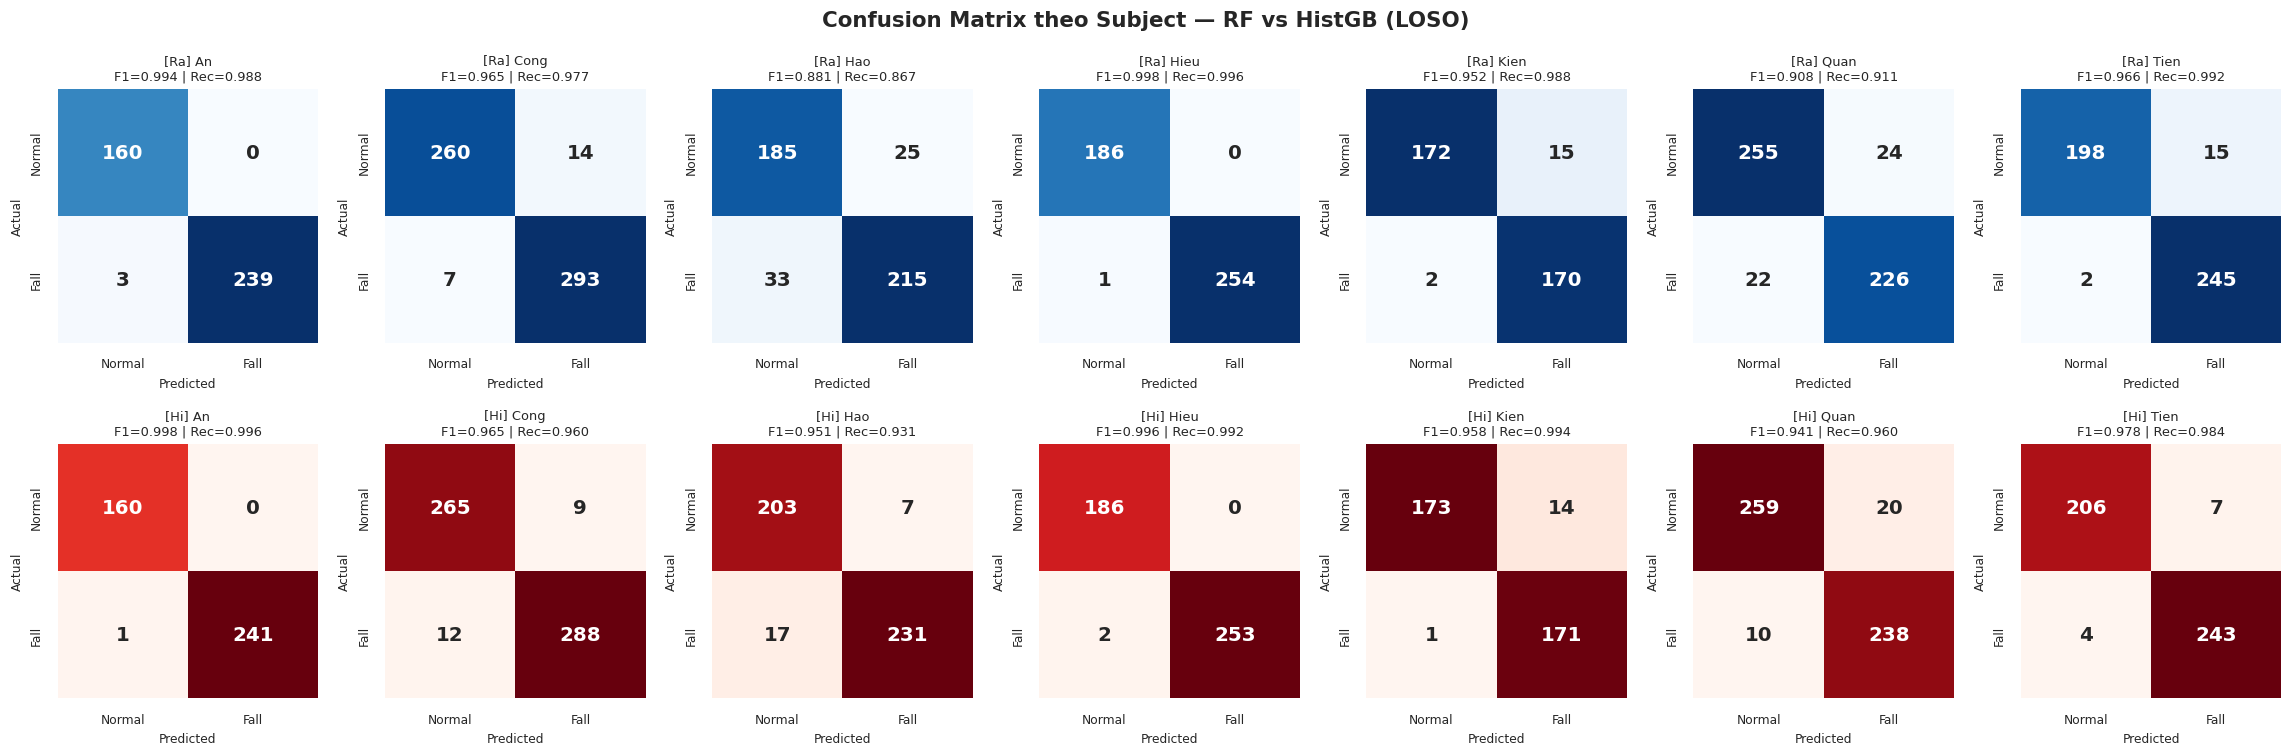

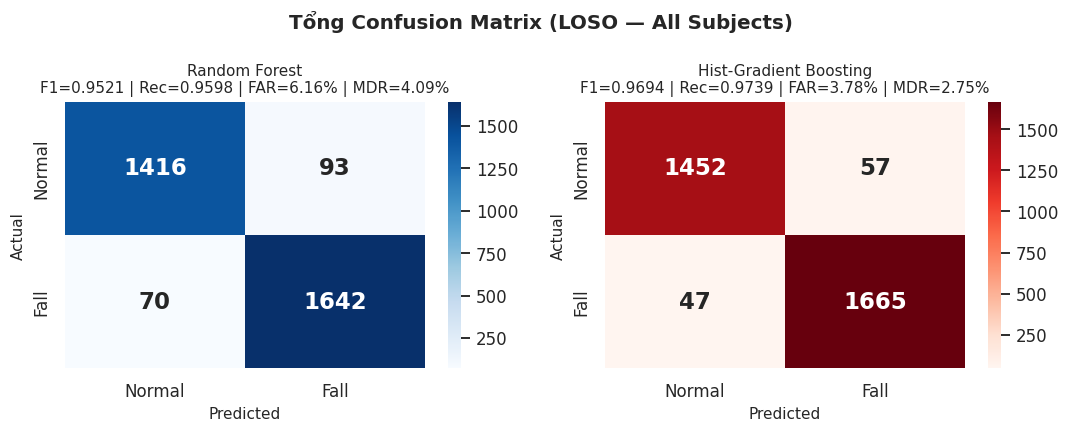

In [ ]:
# ============================================================
# CELL 8: CONFUSION MATRIX VISUALIZATION (Đã Sửa)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ✅ FIX: Dùng 'HistGB' thay vì 'GB'
for model_name in ['RF', 'HistGB']:
    r = results[model_name]
    if len(r['subject']) == 0:
        print(f'⚠️  [{model_name}] Không có fold nào hoàn thành → bỏ qua.')
        continue

n_subjects_rf = len(results['RF']['subject'])
n_subjects_gb = len(results['HistGB']['subject'])
n_cols        = max(n_subjects_rf, n_subjects_gb)

fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 3, 7))
fig.suptitle('Confusion Matrix theo Subject — RF vs HistGB (LOSO)',
             fontsize=14, fontweight='bold')

for row, model_name in enumerate(['RF', 'HistGB']):
    r     = results[model_name]
    label = 'Random Forest' if model_name == 'RF' else 'Hist-Gradient Boosting'
    n_s   = len(r['subject'])

    for col in range(n_cols):
        ax = axes[row][col]
        if col >= n_s:
            ax.axis('off')
            continue

        subj = r['subject'][col]
        cm   = np.array([[r['tn'][col], r['fp'][col]],
                          [r['fn'][col], r['tp'][col]]])

        sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                    cmap='Blues' if model_name == 'RF' else 'Reds',
                    cbar=False,
                    xticklabels=['Normal', 'Fall'],
                    yticklabels=['Normal', 'Fall'],
                    annot_kws={'size': 13, 'weight': 'bold'})
        ax.set_xlabel('Predicted', fontsize=8)
        ax.set_ylabel('Actual',    fontsize=8)
        ax.set_title(f'[{label[:2]}] {subj}\n'
                     f'F1={r["f1"][col]:.3f} | Rec={r["rec"][col]:.3f}',
                     fontsize=8.5)
        ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_loso.png', dpi=150)
plt.show()

# Tổng confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Tổng Confusion Matrix (LOSO — All Subjects)',
             fontsize=13, fontweight='bold')

for ax, model_name in zip(axes, ['RF', 'HistGB']):
    r     = results[model_name]
    label = 'Random Forest' if model_name == 'RF' else 'Hist-Gradient Boosting'
    tn_t  = sum(r['tn']); fp_t = sum(r['fp'])
    fn_t  = sum(r['fn']); tp_t = sum(r['tp'])
    cm    = np.array([[tn_t, fp_t], [fn_t, tp_t]])

    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues' if model_name == 'RF' else 'Reds',
                cbar=True,
                xticklabels=['Normal', 'Fall'],
                yticklabels=['Normal', 'Fall'],
                annot_kws={'size': 15, 'weight': 'bold'})

    far = fp_t / (fp_t + tn_t + 1e-8) * 100
    mdr = fn_t / (fn_t + tp_t + 1e-8) * 100
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual',    fontsize=10)
    ax.set_title(f'{label}\nF1={np.mean(r["f1"]):.4f} | '
                 f'Rec={np.mean(r["rec"]):.4f} | '
                 f'FAR={far:.2f}% | MDR={mdr:.2f}%', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_total.png', dpi=150)
plt.show()

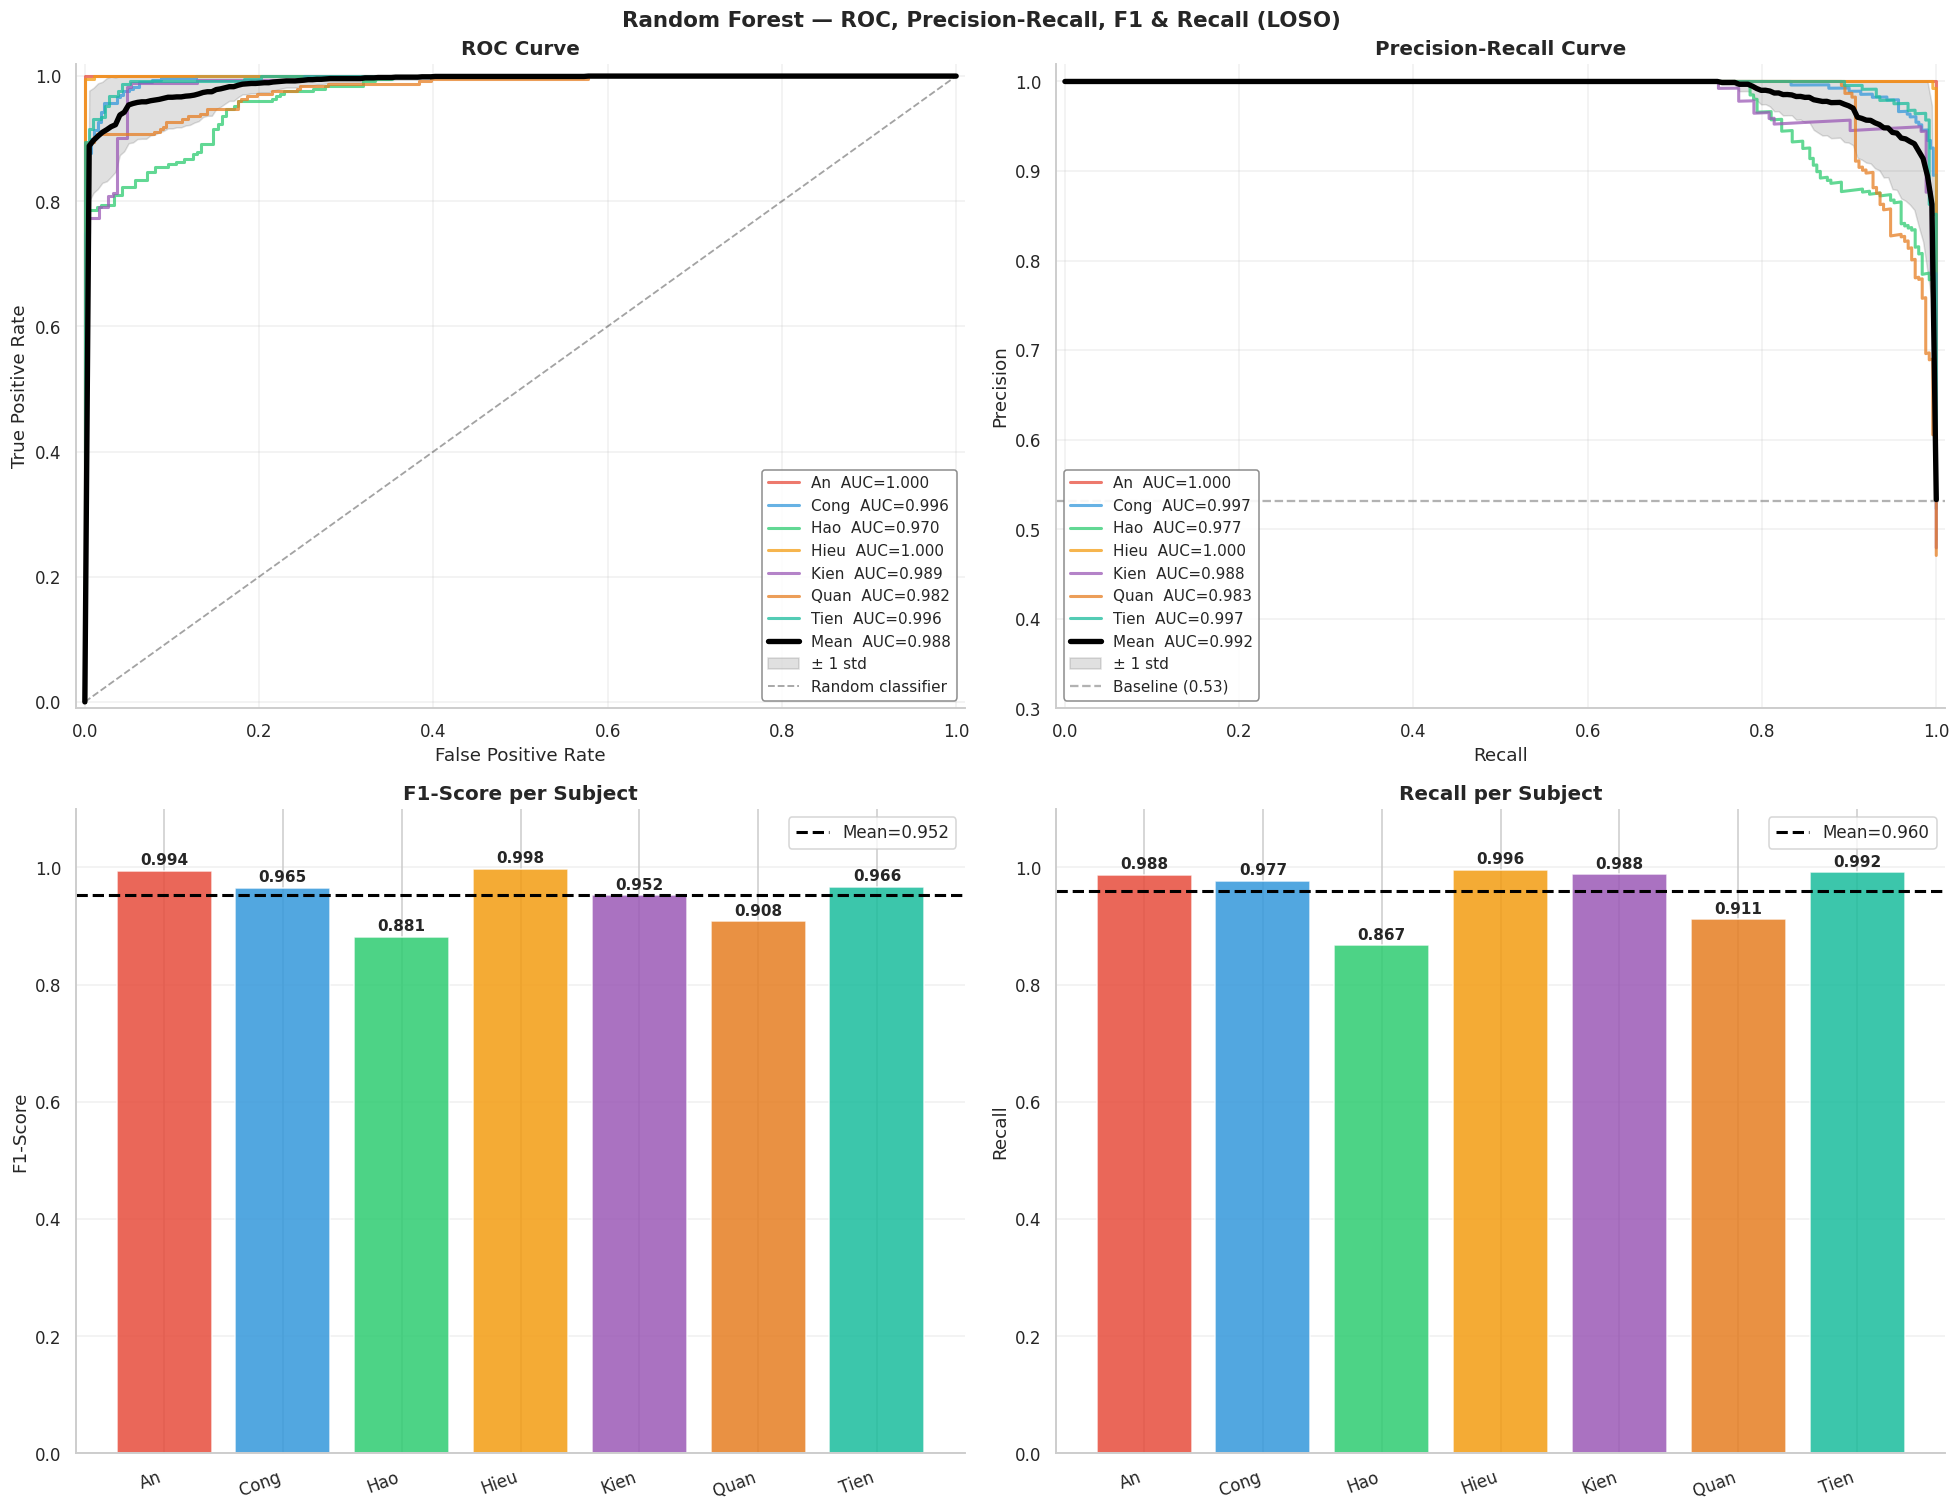

✅ Saved: curves_rf.png

 BẢNG TỔNG HỢP METRICS TỪNG SUBJECT — Random Forest
Subject    |  F1-Score |    Recall |   Precis. |   AUC-ROC |   Thresh.
----------------------------------------------------------------------------
An         |    0.9938 |    0.9876 |    1.0000 |    1.0000 |    0.5223
Cong       |    0.9654 |    0.9767 |    0.9544 |    0.9962 |    0.4907
Hao        |    0.8811 |    0.8669 |    0.8958 |    0.9704 |    0.5437
Hieu       |    0.9980 |    0.9961 |    1.0000 |    1.0000 |    0.5093
Kien       |    0.9524 |    0.9884 |    0.9189 |    0.9892 |    0.4804
Quan       |    0.9076 |    0.9113 |    0.9040 |    0.9816 |    0.4699
Tien       |    0.9665 |    0.9919 |    0.9423 |    0.9963 |    0.5506
----------------------------------------------------------------------------
MEAN (AVG) |    0.9521 |    0.9598 |    0.9451 |    0.9905 |    0.5095



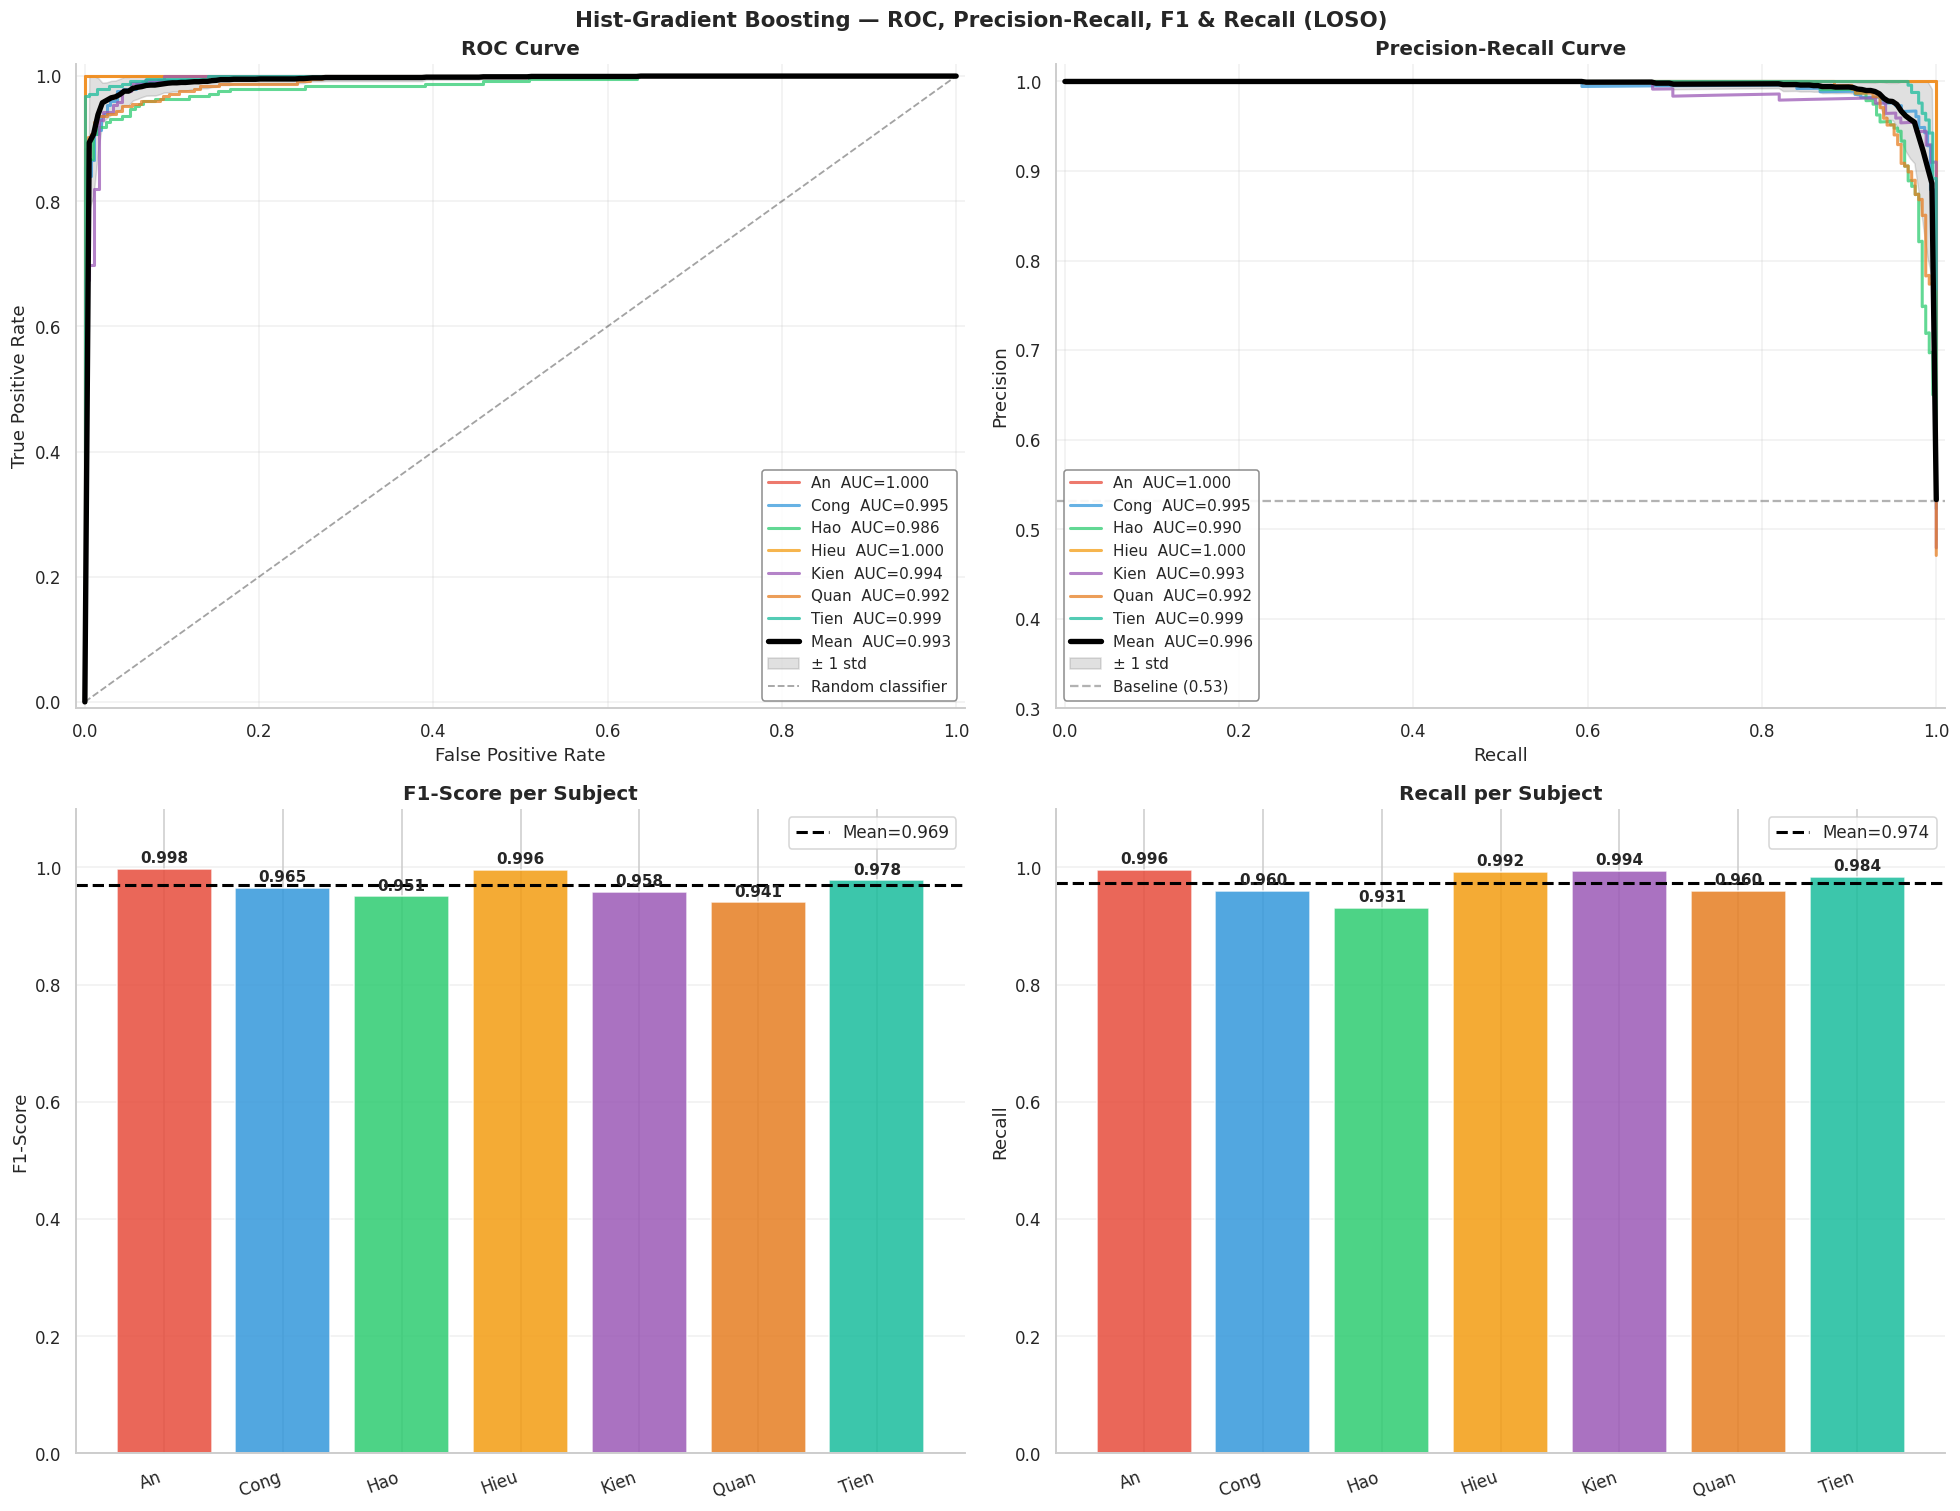

✅ Saved: curves_histgb.png

 BẢNG TỔNG HỢP METRICS TỪNG SUBJECT — Hist-Gradient Boosting
Subject    |  F1-Score |    Recall |   Precis. |   AUC-ROC |   Thresh.
----------------------------------------------------------------------------
An         |    0.9979 |    0.9959 |    1.0000 |    1.0000 |    0.5494
Cong       |    0.9648 |    0.9600 |    0.9697 |    0.9945 |    0.7448
Hao        |    0.9506 |    0.9315 |    0.9706 |    0.9858 |    0.2749
Hieu       |    0.9961 |    0.9922 |    1.0000 |    1.0000 |    0.6026
Kien       |    0.9580 |    0.9942 |    0.9243 |    0.9937 |    0.3854
Quan       |    0.9407 |    0.9597 |    0.9225 |    0.9922 |    0.4742
Tien       |    0.9779 |    0.9838 |    0.9720 |    0.9985 |    0.4434
----------------------------------------------------------------------------
MEAN (AVG) |    0.9694 |    0.9739 |    0.9656 |    0.9950 |    0.4964



In [ ]:
# ============================================================
# CELL 9: ROC CURVE & PR CURVE & F1/RECALL BAR (Đã Sửa + Bảng Text)
# ============================================================
from sklearn.metrics import roc_curve, auc as sk_auc
from sklearn.metrics import average_precision_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

COLORS  = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#e67e22', '#1abc9c']
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X']

# ✅ FIX: Dùng 'HistGB'
for model_name, label in [('RF', 'Random Forest'), ('HistGB', 'Hist-Gradient Boosting')]:

    r = results[model_name]

    subject_to_idx = {subj: i for i, subj in enumerate(r['subject'])}
    valid_subjects  = r['subject']

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    ax_roc, ax_pr  = axes[0]
    ax_f1,  ax_rec = axes[1]

    fig.suptitle(f'{label} — ROC, Precision-Recall, F1 & Recall (LOSO)',
                 fontsize=14, fontweight='bold')

    mean_fpr    = np.linspace(0, 1, 200)
    mean_recall = np.linspace(0, 1, 200)
    tpr_list    = []
    prec_list   = []
    f1_per_fold  = []
    rec_per_fold = []

    for i, test_person in enumerate(valid_subjects):
        idx       = subject_to_idx[test_person]
        test_mask = (persons == test_person)
        y_true    = y_raw[test_mask]
        proba     = r['proba'][idx]

        color = COLORS[i % len(COLORS)]

        # ROC
        fpr, tpr, _ = roc_curve(y_true, proba)
        roc_auc_val = sk_auc(fpr, tpr)
        tpr_interp  = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0
        tpr_list.append(tpr_interp)

        ax_roc.plot(fpr, tpr, color=color, linewidth=2.0, alpha=0.75,
                    label=f'{test_person}  AUC={roc_auc_val:.3f}')

        # PR
        prec_arr, rec_arr, _ = precision_recall_curve(y_true, proba)
        pr_auc_val = average_precision_score(y_true, proba)

        prec_interp = np.interp(mean_recall, rec_arr[::-1], prec_arr[::-1])
        prec_list.append(prec_interp)

        ax_pr.plot(rec_arr, prec_arr, color=color, linewidth=2.0, alpha=0.75,
                   label=f'{test_person}  AUC={pr_auc_val:.3f}')

        f1_per_fold.append(r['f1'][idx])
        rec_per_fold.append(r['rec'][idx])

    # Mean ROC
    mean_tpr     = np.mean(tpr_list, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc_roc = sk_auc(mean_fpr, mean_tpr)
    std_tpr      = np.std(tpr_list, axis=0)

    ax_roc.plot(mean_fpr, mean_tpr, color='black', linewidth=3.5, zorder=5,
                label=f'Mean  AUC={mean_auc_roc:.3f}')
    ax_roc.fill_between(mean_fpr,
                        np.clip(mean_tpr - std_tpr, 0, 1),
                        np.clip(mean_tpr + std_tpr, 0, 1),
                        alpha=0.12, color='black', label='± 1 std')
    ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.4,
                label='Random classifier')

    ax_roc.set_xlim([-0.01, 1.01]); ax_roc.set_ylim([-0.01, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate',  fontsize=12)
    ax_roc.set_title('ROC Curve', fontsize=13, fontweight='bold')
    ax_roc.legend(fontsize=10, loc='lower right', framealpha=0.9, edgecolor='gray')
    ax_roc.grid(True, alpha=0.3); sns.despine(ax=ax_roc)

    # Mean PR
    mean_prec   = np.mean(prec_list, axis=0)
    std_prec    = np.std(prec_list, axis=0)
    mean_auc_pr = np.mean([
        average_precision_score(
            y_raw[persons == s],
            r['proba'][subject_to_idx[s]]
        )
        for s in valid_subjects
    ])
    baseline    = np.sum(y_raw == 1) / len(y_raw)

    ax_pr.plot(mean_recall, mean_prec, color='black', linewidth=3.5, zorder=5,
               label=f'Mean  AUC={mean_auc_pr:.3f}')
    ax_pr.fill_between(mean_recall,
                       np.clip(mean_prec - std_prec, 0, 1),
                       np.clip(mean_prec + std_prec, 0, 1),
                       alpha=0.12, color='black', label='± 1 std')
    ax_pr.axhline(baseline, color='gray', linestyle='--', linewidth=1.5, alpha=0.6,
                  label=f'Baseline ({baseline:.2f})')

    ax_pr.set_xlim([-0.01, 1.01]); ax_pr.set_ylim([0.3, 1.02])
    ax_pr.set_xlabel('Recall',    fontsize=12)
    ax_pr.set_ylabel('Precision', fontsize=12)
    ax_pr.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
    ax_pr.legend(fontsize=10, loc='lower left', framealpha=0.9, edgecolor='gray')
    ax_pr.grid(True, alpha=0.3); sns.despine(ax=ax_pr)

    # F1 per Subject
    x_pos   = np.arange(len(valid_subjects))
    mean_f1 = np.mean(f1_per_fold)
    colors  = [COLORS[i % len(COLORS)] for i in range(len(valid_subjects))]

    bars = ax_f1.bar(x_pos, f1_per_fold, color=colors, alpha=0.85)
    ax_f1.axhline(mean_f1, color='black', linestyle='--', linewidth=2,
                  label=f'Mean={mean_f1:.3f}')
    for bar, val in zip(bars, f1_per_fold):
        ax_f1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax_f1.set_xticks(x_pos)
    ax_f1.set_xticklabels(valid_subjects, rotation=20, ha='right', fontsize=11)
    ax_f1.set_ylim([0, 1.1])
    ax_f1.set_ylabel('F1-Score', fontsize=12)
    ax_f1.set_title('F1-Score per Subject', fontsize=13, fontweight='bold')
    ax_f1.legend(fontsize=11); ax_f1.grid(axis='y', alpha=0.3)
    sns.despine(ax=ax_f1)

    # Recall per Subject
    mean_rec = np.mean(rec_per_fold)

    bars = ax_rec.bar(x_pos, rec_per_fold, color=colors, alpha=0.85)
    ax_rec.axhline(mean_rec, color='black', linestyle='--', linewidth=2,
                   label=f'Mean={mean_rec:.3f}')
    for bar, val in zip(bars, rec_per_fold):
        ax_rec.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax_rec.set_xticks(x_pos)
    ax_rec.set_xticklabels(valid_subjects, rotation=20, ha='right', fontsize=11)
    ax_rec.set_ylim([0, 1.1])
    ax_rec.set_ylabel('Recall', fontsize=12)
    ax_rec.set_title('Recall per Subject', fontsize=13, fontweight='bold')
    ax_rec.legend(fontsize=11); ax_rec.grid(axis='y', alpha=0.3)
    sns.despine(ax=ax_rec)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'curves_{model_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: curves_{model_name.lower()}.png')

    # ============================================================
    # 💡 BẢNG TEXT BÁO CÁO TỔNG HỢP (MỚI THÊM)
    # ============================================================
    print(f'\n{"="*76}')
    print(f' BẢNG TỔNG HỢP METRICS TỪNG SUBJECT — {label}')
    print(f'{"="*76}')
    print(f'{"Subject":<10} | {"F1-Score":>9} | {"Recall":>9} | {"Precis.":>9} | {"AUC-ROC":>9} | {"Thresh.":>9}')
    print('-' * 76)

    f1_l, rec_l, pre_l, auc_l, thr_l = [], [], [], [], []

    for test_person in valid_subjects:
        idx  = subject_to_idx[test_person]
        f1_v = r['f1'][idx]
        re_v = r['rec'][idx]
        pr_v = r['prec'][idx]
        au_v = r['auc'][idx]
        th_v = r['threshold'][idx]

        f1_l.append(f1_v); rec_l.append(re_v); pre_l.append(pr_v)
        auc_l.append(au_v); thr_l.append(th_v)

        print(f'{test_person:<10} | {f1_v:>9.4f} | {re_v:>9.4f} | {pr_v:>9.4f} | {au_v:>9.4f} | {th_v:>9.4f}')

    print('-' * 76)
    print(f'{"MEAN (AVG)":<10} | {np.mean(f1_l):>9.4f} | {np.mean(rec_l):>9.4f} | {np.mean(pre_l):>9.4f} | {np.mean(auc_l):>9.4f} | {np.mean(thr_l):>9.4f}')
    print(f'{"="*76}\n')

In [ ]:
# ============================================================
# CELL 7: TRAIN FINAL MODEL (Đã Sửa)
# ============================================================
import json
from collections import Counter
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier # ✅ FIX: Sửa Import

def get_best_overall_params(params_list, scores_list):
    """Chọn bộ params của fold có Inner CV score cao nhất."""
    best_idx = int(np.argmax(scores_list))
    return params_list[best_idx]

# ✅ FIX: Lấy tham số và đổi key 'GB' -> 'HistGB'
rf_best_params = get_best_overall_params(results['RF']['best_params'], results['RF']['best_score'])
histgb_best_params = get_best_overall_params(results['HistGB']['best_params'], results['HistGB']['best_score'])

# ✅ FIX: Bỏ tiền tố 'model__' ra khỏi dictionary để có thể pass vào mô hình
rf_clean_params = {k.replace('model__', ''): v for k, v in rf_best_params.items()}
histgb_clean_params = {k.replace('model__', ''): v for k, v in histgb_best_params.items()}

print('\n' + '='*60)
print('HP tốt nhất (Nguyên bộ mode qua các fold):')
print(f'  RF: {rf_clean_params}')
print(f'  HistGB: {histgb_clean_params}')

# Train final model
print('\nTraining final models trên toàn bộ data...')

scaler_final = StandardScaler()
X_all_s      = scaler_final.fit_transform(X_raw)

# ✅ FIX: Dùng clean parameters và class HistGB
rf_final = RandomForestClassifier(**rf_clean_params, class_weight='balanced',
                                   n_jobs=-1, random_state=SEED)
histgb_final = HistGradientBoostingClassifier(**histgb_clean_params, random_state=SEED)

rf_final.fit(X_all_s, y_raw)
print('✅ Random Forest trained')
histgb_final.fit(X_all_s, y_raw)
print('✅ Hist-Gradient Boosting trained')

rf_final_thr = float(np.median(results['RF']['threshold']))
histgb_final_thr = float(np.median(results['HistGB']['threshold']))

print('\n' + '='*60)
print('FINAL DEPLOYMENT THRESHOLDS (Median of LOSO):')
print(f'  RF Threshold: {rf_final_thr:.4f}')
print(f'  HistGB Threshold: {histgb_final_thr:.4f}')

# Save
rf_path     = OUTPUT_DIR / 'final_rf_model.joblib'
gb_path     = OUTPUT_DIR / 'final_histgb_model.joblib' # ✅ Đổi tên file cho chuẩn
scaler_path = OUTPUT_DIR / 'scaler_final.pkl'
config_path = OUTPUT_DIR / 'config_feature_based.json'

joblib.dump(rf_final,     rf_path)
joblib.dump(histgb_final, gb_path)
joblib.dump(scaler_final, scaler_path)

def safe_rate(num, denom):
    return round(num / (denom + 1e-8) * 100, 2)

config = {
    'approach'          : 'feature_based',
    'models'            : ['Random Forest', 'Hist-Gradient Boosting'],
    'n_features'        : int(X_raw.shape[1]),
    'feature_names'     : FEATURE_NAMES,
    'window_size'       : WINDOW_SIZE,
    'sample_rate'       : SAMPLE_RATE,
    'overlap_ratio'     : OVERLAP_RATIO,
    'n_hot_windows'     : N_HOT_WINDOWS,
    'exclude_subfolders': EXCLUDE_SUBFOLDERS,
    'class_names'       : CLASS_NAMES,
    'final_deployment': {
        'RF': {'params': rf_clean_params, 'optimal_threshold': rf_final_thr},
        'HistGB': {'params': histgb_clean_params, 'optimal_threshold': histgb_final_thr},
    },
    'loso_results': {
        mn: {
            'f1'              : round(float(np.mean(results[mn]['f1'])),  4),
            'recall'          : round(float(np.mean(results[mn]['rec'])), 4),
            'prec'            : round(float(np.mean(results[mn]['prec'])),4),
            'auc'             : round(float(np.mean(results[mn]['auc'])), 4),
            'false_alarm_rate': safe_rate(sum(results[mn]['fp']),
                                          sum(results[mn]['fp']) + sum(results[mn]['tn'])),
            'miss_detect_rate': safe_rate(sum(results[mn]['fn']),
                                          sum(results[mn]['fn']) + sum(results[mn]['tp'])),
            'per_fold': [
                {'subject': s, 'f1': round(f, 4), 'rec': round(r, 4),
                 'auc': round(a, 4), 'params': p}
                for s, f, r, a, p in zip(results[mn]['subject'], results[mn]['f1'],
                                         results[mn]['rec'], results[mn]['auc'],
                                         results[mn]['best_params'])
            ],
        }
        for mn in ['RF', 'HistGB'] # ✅ FIX
    },
    'dataset': {
        'total_sessions': len(all_sessions),
        'total_windows' : int(len(X_raw)),
        'persons'       : list(np.unique(persons)),
    },
}

with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f'\n✅ RF model  : {rf_path}')
print(f'✅ HistGB model: {gb_path}')
print(f'✅ Scaler    : {scaler_path}')
print(f'✅ Config    : {config_path}')

print(f'\n── LOSO Summary ─────────────────────────────────────────')
print(f'{"":8} {"F1":>8} {"Recall":>8} {"FAR%":>8} {"MDR%":>8}')
print('─'*40)
for mn in ['RF', 'HistGB']:
    r = results[mn]
    print(f'{mn:8} {np.mean(r["f1"]):>8.4f} {np.mean(r["rec"]):>8.4f} '
          f'{safe_rate(sum(r["fp"]), sum(r["fp"])+sum(r["tn"])):>8.2f} '
          f'{safe_rate(sum(r["fn"]), sum(r["fn"])+sum(r["tp"])):>8.2f}')
print(f'\nFinal RF params     : {rf_clean_params}')
print(f'Final HistGB params : {histgb_clean_params}')


HP tốt nhất (Nguyên bộ mode qua các fold):
  RF: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15}
  HistGB: {'min_samples_leaf': 4, 'max_iter': 200, 'max_depth': 3, 'learning_rate': 0.2, 'l2_regularization': 0.0}

Training final models trên toàn bộ data...
✅ Random Forest trained
✅ Hist-Gradient Boosting trained

FINAL DEPLOYMENT THRESHOLDS (Median of LOSO):
  RF Threshold: 0.5093
  HistGB Threshold: 0.4742

✅ RF model  : /content/drive/MyDrive/data_pbl5/rfgb_loso_cross_hyperparameter_tuning_2/final_rf_model.joblib
✅ HistGB model: /content/drive/MyDrive/data_pbl5/rfgb_loso_cross_hyperparameter_tuning_2/final_histgb_model.joblib
✅ Scaler    : /content/drive/MyDrive/data_pbl5/rfgb_loso_cross_hyperparameter_tuning_2/scaler_final.pkl
✅ Config    : /content/drive/MyDrive/data_pbl5/rfgb_loso_cross_hyperparameter_tuning_2/config_feature_based.json

── LOSO Summary ─────────────────────────────────────────
               F1   Recall     FAR%     MDR%
─────

In [ ]:
# ============================================================
# CELL 10: BẢNG SO SÁNH CHI TIẾT (RF vs HistGB)
# ============================================================
import numpy as np

# Đảm bảo hàm safe_rate đã có sẵn
def safe_rate(num, denom):
    return round(num / (denom + 1e-8) * 100, 2)

# Tính toán FAR và MDR tổng
rf_far = safe_rate(sum(results['RF']['fp']), sum(results['RF']['fp']) + sum(results['RF']['tn']))
rf_mdr = safe_rate(sum(results['RF']['fn']), sum(results['RF']['fn']) + sum(results['RF']['tp']))

gb_far = safe_rate(sum(results['HistGB']['fp']), sum(results['HistGB']['fp']) + sum(results['HistGB']['tn']))
gb_mdr = safe_rate(sum(results['HistGB']['fn']), sum(results['HistGB']['fn']) + sum(results['HistGB']['tp']))

# In bảng
print("\n" + "="*92)
print(f"| {'BẢNG SO SÁNH: RANDOM FOREST (RF) & HIST-GRADIENT BOOSTING (HistGB)':^88} |")
print("="*92)
print(f"| {'Tiêu chí':<25} | {'Random Forest (RF)':<30} | {'HistGB':<27} |")
print("-" * 92)
print(f"| {'Bản chất thuật toán':<25} | {'Bagging (Song song)':<30} | {'Boosting (Tuần tự, Hist)':<27} |")
print("-" * 92)

# Khối 1: Thông số (Hyperparameters)
print(f"| {'Best n_estimators/iter':<25} | {str(rf_clean_params.get('n_estimators', 'N/A')):<30} | {str(histgb_clean_params.get('max_iter', 'N/A')):<27} |")
print(f"| {'Best max_depth':<25} | {str(rf_clean_params.get('max_depth', 'N/A')):<30} | {str(histgb_clean_params.get('max_depth', 'N/A')):<27} |")
print(f"| {'Best min_samples_leaf':<25} | {str(rf_clean_params.get('min_samples_leaf', 'N/A')):<30} | {str(histgb_clean_params.get('min_samples_leaf', 'N/A')):<27} |")
print(f"| {'Best max_features':<25} | {str(rf_clean_params.get('max_features', 'N/A')):<30} | {'N/A (Sử dụng tất cả)':<27} |")
print(f"| {'Best learning_rate':<25} | {'N/A':<30} | {str(histgb_clean_params.get('learning_rate', 'N/A')):<27} |")
print(f"| {'Best l2_regularization':<25} | {'N/A':<30} | {str(histgb_clean_params.get('l2_regularization', 'N/A')):<27} |")
print("-" * 92)

# Khối 2: Kết quả đánh giá (Mean Metrics)
print(f"| {'Mean F1-Score':<25} | {np.mean(results['RF']['f1']):<30.4f} | {np.mean(results['HistGB']['f1']):<27.4f} |")
print(f"| {'Mean Recall':<25} | {np.mean(results['RF']['rec']):<30.4f} | {np.mean(results['HistGB']['rec']):<27.4f} |")
print(f"| {'Mean Precision':<25} | {np.mean(results['RF']['prec']):<30.4f} | {np.mean(results['HistGB']['prec']):<27.4f} |")
print(f"| {'Mean AUC':<25} | {np.mean(results['RF']['auc']):<30.4f} | {np.mean(results['HistGB']['auc']):<27.4f} |")
print(f"| {'False Alarm Rate (FAR)':<25} | {str(rf_far) + '%':<30} | {str(gb_far) + '%':<27} |")
print(f"| {'Miss Detect Rate (MDR)':<25} | {str(rf_mdr) + '%':<30} | {str(gb_mdr) + '%':<27} |")
print(f"| {'Final Threshold':<25} | {rf_final_thr:<30.4f} | {histgb_final_thr:<27.4f} |")
print("="*92)


|            BẢNG SO SÁNH: RANDOM FOREST (RF) & HIST-GRADIENT BOOSTING (HistGB)            |
| Tiêu chí                  | Random Forest (RF)             | HistGB                      |
--------------------------------------------------------------------------------------------
| Bản chất thuật toán       | Bagging (Song song)            | Boosting (Tuần tự, Hist)    |
--------------------------------------------------------------------------------------------
| Best n_estimators/iter    | 200                            | 200                         |
| Best max_depth            | 15                             | 3                           |
| Best min_samples_leaf     | 2                              | 4                           |
| Best max_features         | sqrt                           | N/A (Sử dụng tất cả)        |
| Best learning_rate        | N/A                            | 0.2                         |
| Best l2_regularization    | N/A                            | 0.0   